In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch
from math import pi

### Prepare

In [2]:
# read all data machine learning experiment
df1 = pd.read_csv('../results/clean_experiment/Machine_Learning/f1_final_experiment.csv')
df2 = pd.read_csv('../results/clean_experiment/Machine_Learning/f2_final_experiment.csv')
df3 = pd.read_csv('../results/clean_experiment/Machine_Learning/f3_final_experiment.csv')
df4 = pd.read_csv('../results/clean_experiment/Machine_Learning/f4_final_experiment.csv')
df_ml_final = pd.concat([df1, df2, df3, df4], ignore_index=True)

# save df_ml_final to csv
df_ml_final.to_csv('../results/clean_experiment/Machine_Learning/final_ml_experiment.csv', index=False)

In [3]:
df_dl = pd.read_csv('../results/clean_experiment/Deep_Learning/DL_final_experiment.csv')
df_ml_final = pd.read_csv('../results/clean_experiment/Machine_Learning/final_ml_experiment.csv')

In [4]:
# concat deep learning final with machine learning final
df_final = pd.concat([df_ml_final, df_dl], ignore_index=True)
df_final.to_csv('../results/clean_experiment/final_experiment.csv', index=False)

### Summary Analysis

In [ ]:

dl_models = ['BiLSTM', 'Transformer', 'CNN-1D', 'Deep-MLP', 'BiGRU', 'ResNet-MLP', 'Attention-MLP', 'CNN-LSTM']
ml_models = ['LightGBM', 'XGBoost', 'GradientBoosting', 'RandomForest', 'Naive Bayes', 'LogisticRegression', 'ElasticNetLR', 'SVM', 'Stacking']

def get_score(model, version, metric):
    try:
        if metric == 'SEN':
            return df[(df['Model'] == model) & (df['Data versioning'] == version) & (df['Label'] == 1)][metric].values[0]
        else:
            return df[(df['Model'] == model) & (df['Data versioning'] == version) & (df['Label'] == 0)][metric].values[0]
    except IndexError:
        return 0

metrics = [
    ('F1_macro', 'F1 Macro Score'),
    ('ACC balanced', 'ACC Balanced Score'),
    ('ROC_AUC', 'ROC AUC Score'),
    ('SEN', 'Sensitivity (Label 1)')
]

# Config style
plt.style.use('seaborn-v0_8-paper')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

color_raw = '#B0BEC5'        
color_smote = '#1E88E5'     
color_highlight = '#E53935'  

for metric_col, metric_name in metrics:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

    width = 0.35
    x_ml = np.arange(len(ml_models))
    x_dl = np.arange(len(dl_models))

    ml_raw = [get_score(m, 'machine_learning_raw', metric_col) for m in ml_models]
    ml_smote = [get_score(m, 'machine_learning', metric_col) for m in ml_models]
    dl_raw = [get_score(m, 'deep_learning_raw', metric_col) for m in dl_models]
    dl_smote = [get_score(m, 'deep_learning', metric_col) for m in dl_models]

    rects_ml_raw = ax1.bar(x_ml - width/2, ml_raw, width, color=color_raw, edgecolor='black', linewidth=1)
    rects_ml_smote = ax1.bar(x_ml + width/2, ml_smote, width, color=color_smote, edgecolor='black', linewidth=1)
    
    stacking_idx = ml_models.index('Stacking')
    rects_ml_smote[stacking_idx].set_color(color_highlight)
    rects_ml_smote[stacking_idx].set_edgecolor('black') 

    rects_dl_raw = ax2.bar(x_dl - width/2, dl_raw, width, color=color_raw, edgecolor='black', linewidth=1)
    rects_dl_smote = ax2.bar(x_dl + width/2, dl_smote, width, color=color_smote, edgecolor='black', linewidth=1)

    ax1.set_title('Machine Learning', fontsize=16, fontweight='bold', pad=15)
    ax1.set_ylabel(metric_name, fontsize=14, fontweight='bold')
    ax1.set_xticks(x_ml)
    ax1.set_xticklabels(ml_models, rotation=45, ha='right', fontsize=12, fontweight='bold')
    ax1.set_ylim(0, 1.25) 
    ax1.grid(axis='y', linestyle='--', alpha=0.5) 

    ax2.set_title('Deep Learning', fontsize=16, fontweight='bold', pad=15)
    ax2.set_xticks(x_dl)
    ax2.set_xticklabels(dl_models, rotation=45, ha='right', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', linestyle='--', alpha=0.5)

    def autolabel(rects, ax):
        for rect in rects:
            height = rect.get_height()
            if pd.notna(height) and height > 0:
                ax.annotate(f'{height:.3f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 4),  
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=10, rotation=45, fontweight='bold')

    autolabel(rects_ml_raw, ax1)
    autolabel(rects_ml_smote, ax1)
    autolabel(rects_dl_raw, ax2)
    autolabel(rects_dl_smote, ax2)

    # Legend
    legend_elements = [
        Patch(facecolor=color_raw, edgecolor='black', label='No SMOTE (Raw)'),
        Patch(facecolor=color_smote, edgecolor='black', label='With SMOTE (Typical)'),
        Patch(facecolor=color_highlight, edgecolor='black', label='With SMOTE (Highlight: Stacking)')
    ]
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.08), 
               ncol=3, fontsize=14, frameon=True, edgecolor='black')
    
    # Title
    fig.suptitle(f'Comparison of {metric_name}: Affected by SMOTE and Proposed Stacking', 
                 fontsize=20, fontweight='bold', y=1.15)

    plt.tight_layout()
    plt.savefig(f'Highlight_{metric_col}_v2.png', dpi=300, bbox_inches='tight')
    plt.close()

### Stacking && Smote

In [2]:
df_model = pd.read_excel('../results/clean_experiment/model_svm_smote.xlsx')
df_svm_smote = pd.read_excel('../results/clean_experiment/final_experiment.xlsx')

#### STACKING

In [27]:
# WHY STACKING MODEL
df = df_model.copy() 

df_0 = df[df['Label'] == 0].copy()
df_1 = df[df['Label'] == 1].copy()

df_merged = pd.merge(
    df_0[['Model', 'F1_macro', 'MCC', 'PR_AUC', 'ROC_AUC', 'ACC balanced']],
    df_1[['Model', 'PPV', 'SEN']],
    on=['Model'],
    how='inner'
)

summary_df = df_merged.sort_values(by='F1_macro', ascending=False)

output_path = '../results/clean_experiment/analysis/model_summary.csv'
summary_df.round(4).to_csv(output_path, index=False)



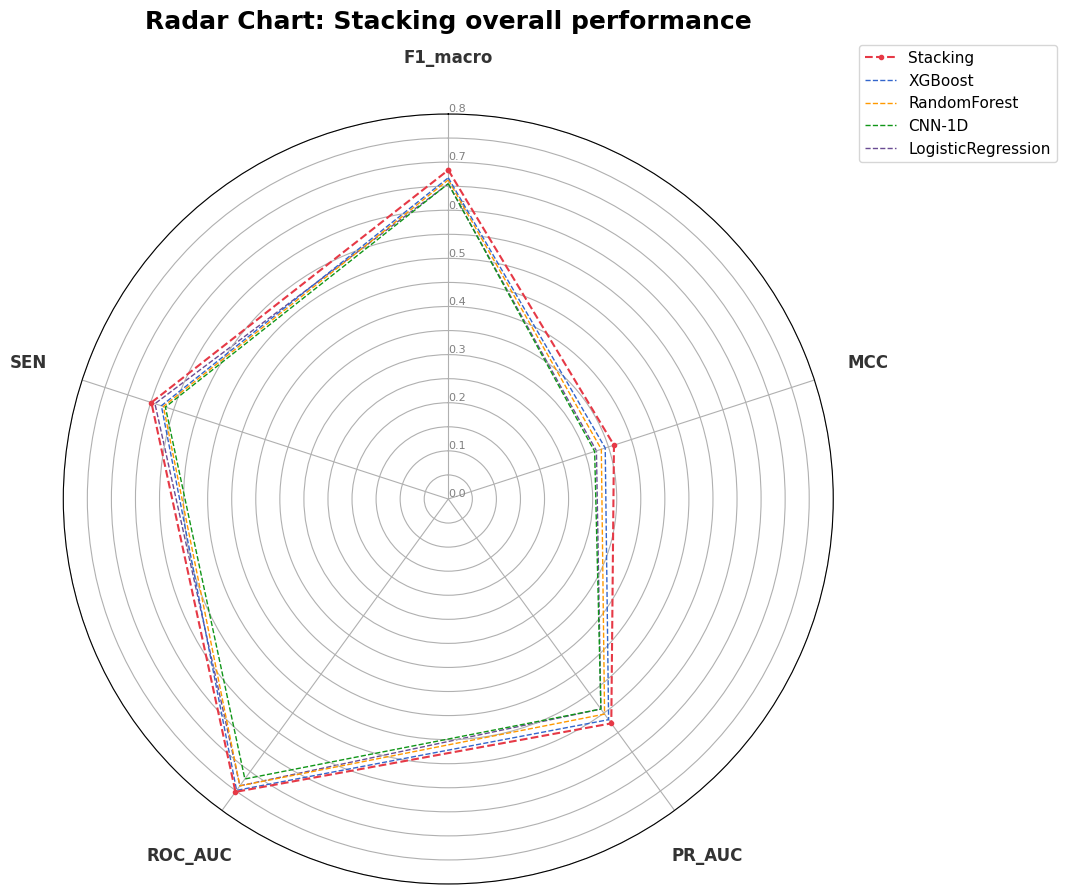

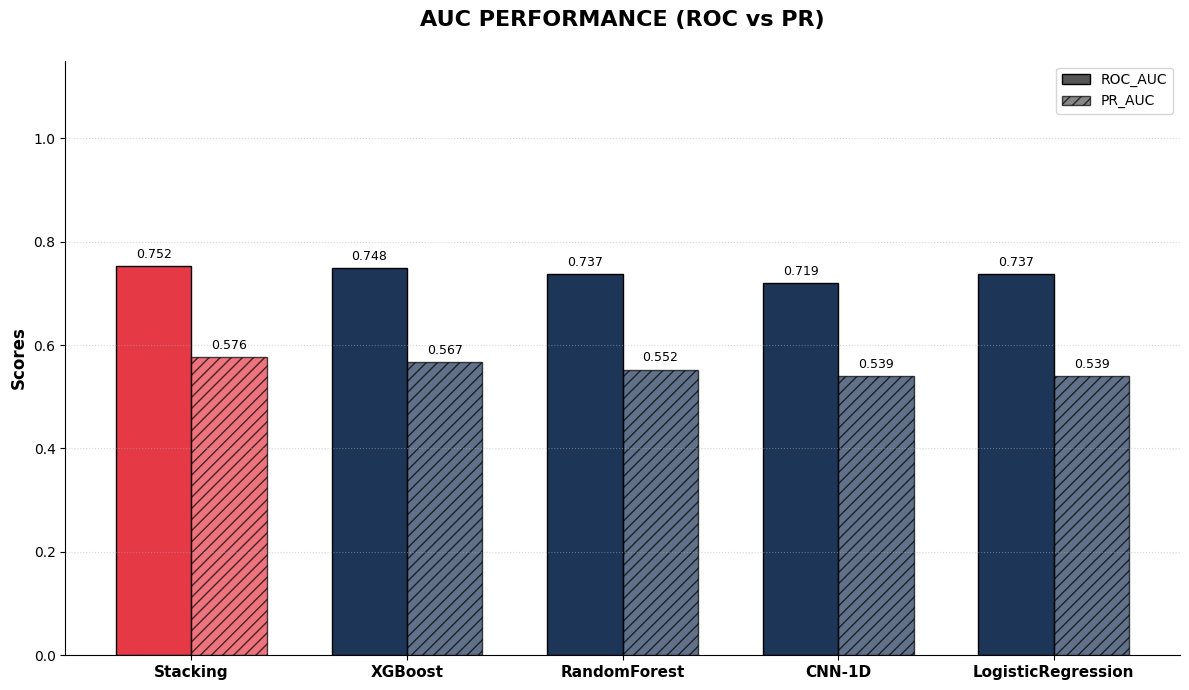

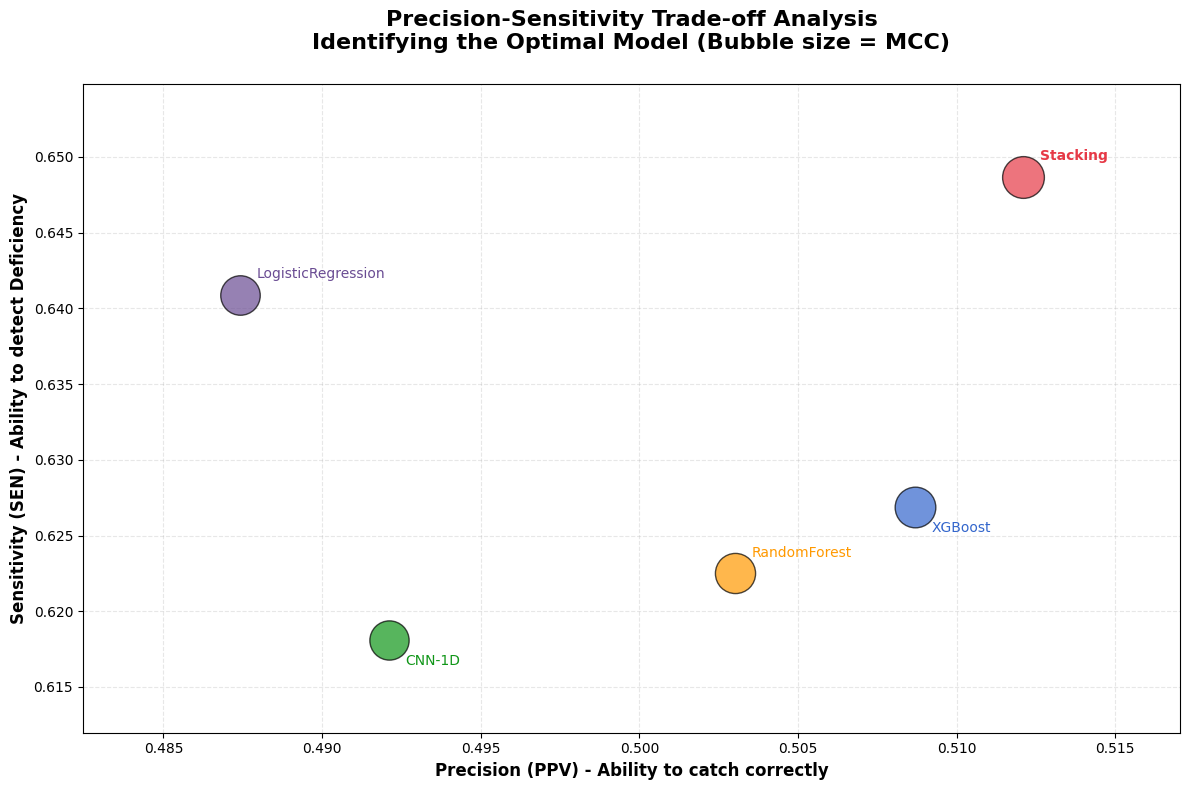

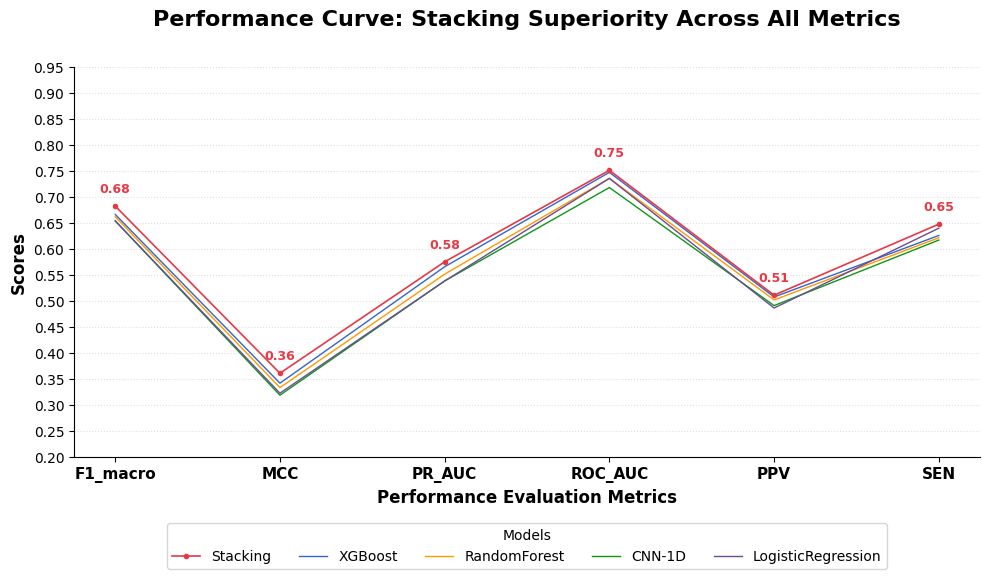

In [11]:
df = pd.read_csv('../results/clean_experiment/analysis/model_summary.csv',  index_col='Model')

top_models = df.index[:5].tolist()

stack_color = '#E63946'
other_colors = ["#3366CC", "#FF9900", "#109618", "#6A4C93"] 

# CHART 1: RADAR CHART 
metrics_radar = ['F1_macro', 'MCC', 'PR_AUC', 'ROC_AUC', 'SEN']
N = len(metrics_radar)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig1, ax1 = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
ax1.set_theta_offset(pi / 2)
ax1.set_theta_direction(-1)

for i, model in enumerate(top_models):
    values = df.loc[model, metrics_radar].values.flatten().tolist()
    values += values[:1]
    
    if model == 'Stacking':
        color = stack_color
        lw = 1.5      
        marker = 'o'                   
        z = 10            
        alpha_fill = 0.25  
    else:
        color = other_colors[i-1]
        lw = 1                   
        marker = ''      
        z = 5 - i         
        alpha_fill = 0.05  
        
    ax1.plot(angles, values, linewidth=lw, linestyle='--', color=color, 
             marker=marker, markersize=3,
             label=f'{model}' if model=='Stacking' else model, 
             zorder=z)

ymin = 0
ymax = 0.8
ax1.set_ylim(ymin, ymax) 

grid_ticks = np.arange(ymin, ymax + 0.01, 0.05)
ax1.set_yticks(grid_ticks)

ax1.set_yticklabels([f"{t:.1f}" if round(t*100)%10==0 else "" for t in grid_ticks], color="grey", size=8)

plt.xticks(angles[:-1], metrics_radar, color='#333333', size=12, fontweight='bold')
ax1.tick_params(axis='x', pad=30) 
ax1.set_rlabel_position(0)

plt.title('Radar Chart: Stacking overall performance', size=18, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11, frameon=True)

plt.savefig('stacking_chart1_radar_final.png', dpi=300, bbox_inches='tight')

# CHART 2: AUC CHART
# CHART 2: AUC PERFORMANCE (ROC vs PR) WITH HATCH PATTERNS
fig2, ax2 = plt.subplots(figsize=(12, 7))

x = np.arange(len(top_models)) 
width = 0.35  

for i, model in enumerate(top_models):
    roc_val = df.loc[model, 'ROC_AUC']
    pr_val = df.loc[model, 'PR_AUC']
    
    current_color = stack_color if model == 'Stacking' else '#1D3557'
    
    ax2.bar(i - width/2, roc_val, width, color=current_color, 
            edgecolor='black', linewidth=1, label='ROC_AUC' if i == 0 else "")
    
    ax2.bar(i + width/2, pr_val, width, color=current_color, hatch='///',
            edgecolor='black', linewidth=1, alpha=0.7, label='PR_AUC' if i == 0 else "")
    
    ax2.text(i - width/2, roc_val + 0.01, f'{roc_val:.3f}', ha='center', va='bottom', fontsize=9)
    ax2.text(i + width/2, pr_val + 0.01, f'{pr_val:.3f}', ha='center', va='bottom', fontsize=9)

ax2.set_xticks(x)
ax2.set_xticklabels(top_models, fontsize=11, fontweight='bold')
ax2.set_ylabel('Scores', fontsize=12, fontweight='bold')
ax2.set_title('AUC PERFORMANCE (ROC vs PR)', fontsize=16, fontweight='bold', pad=25)

ax2.set_ylim(0, 1.15)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', linestyle=':', alpha=0.5)

import matplotlib.patches as mpatches
roc_leg = mpatches.Patch(facecolor='#555555', edgecolor='black', label='ROC_AUC')
pr_leg = mpatches.Patch(facecolor='#555555', edgecolor='black', hatch='///', alpha=0.7, label='PR_AUC')

ax2.legend(handles=[roc_leg, pr_leg], loc='upper right', frameon=True)

plt.tight_layout()
plt.savefig('stacking_chart2_hatch_final.png', dpi=300)
plt.show()

# CHART 3: TRADE-OFF SCATTER 
fig3, ax3 = plt.subplots(figsize=(12, 8))

for i, model in enumerate(top_models):
    row = df.loc[model]
    color = stack_color if model == 'Stacking' else other_colors[i-1]
    size = row['MCC'] * 2500 
    
    ax3.scatter(row['PPV'], row['SEN'], s=size, color=color, alpha=0.7, 
                edgecolor='black', zorder=5 if model=='Stacking' else 3)
    
    offset_y = 12 if i % 2 == 0 else -18
    ax3.annotate(model, (row['PPV'], row['SEN']), xytext=(12, offset_y), 
                 textcoords='offset points', fontweight='bold' if model=='Stacking' else 'normal', 
                 color=color, fontsize=10, ha='left')

ax3.set_xlabel('Precision (PPV) - Ability to catch correctly', fontsize=12, fontweight='bold')
ax3.set_ylabel('Sensitivity (SEN) - Ability to detect Deficiency', fontsize=12, fontweight='bold')
ax3.set_title('Precision-Sensitivity Trade-off Analysis\nIdentifying the Optimal Model (Bubble size = MCC)', 
             fontsize=16, fontweight='bold', pad=25)
ax3.grid(True, linestyle='--', alpha=0.3)
ax3.margins(0.2) 

plt.tight_layout()
plt.savefig('stacking_chart3_tradeoff_final.png', dpi=300)

# CHART 4: LINE CHART (Performance Curve 
metrics_line = ['F1_macro', 'MCC', 'PR_AUC', 'ROC_AUC', 'PPV', 'SEN']
x_pos = np.arange(len(metrics_line))

fig, ax = plt.subplots(figsize=(10, 6))

all_values = []

for i, model in enumerate(top_models):
    y_vals = df.loc[model, metrics_line].values.flatten()
    all_values.extend(y_vals)
    
    if model == 'Stacking':
        ax.plot(x_pos, y_vals, marker='o', markersize=3, linewidth=1.2, 
                color=stack_color, label=f'{model}', zorder=10)
        
        for x, y in zip(x_pos, y_vals):
            ax.text(x, y + 0.02, f'{y:.2f}', color=stack_color, 
                    fontweight='bold', ha='center',va='bottom', fontsize=9)
    else:
        ax.plot(x_pos, y_vals, marker='', markersize=4, linewidth=1, 
                 color=other_colors[i-1], label=model, zorder=5)

y_min_val, y_max_val = min(all_values), max(all_values)

ax.set_ylim(y_min_val - 0.1, y_max_val + 0.15) 

y_ticks = np.arange(round(y_min_val - 0.1, 1), round(y_max_val + 0.2, 1), 0.05)
ax.set_yticks(y_ticks)

ax.set_xticks(x_pos)
ax.set_xticklabels(metrics_line, fontsize=11, fontweight='bold')
ax.set_xlabel('Performance Evaluation Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Scores', fontsize=12, fontweight='bold')

ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title('Performance Curve: Stacking Superiority Across All Metrics', 
             fontsize=16, fontweight='bold', pad=30)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
          ncol=len(top_models), title="Models", frameon=True)

plt.tight_layout()
plt.savefig('stacking_chart4_line_final.png', dpi=300, bbox_inches='tight')
plt.show()

#### SVM SMOTE

In [5]:
#  Create file summary_smote.csv with mean, min, max of each metric for each SMOTE technique
df = df_svm_smote.copy()

def get_smote_tech(ver):
    parts = str(ver).split('__')
    if len(parts) > 0:
        return parts[-1] 
    return 'unknown'

df['SMOTE_Technique'] = df['Data versioning'].apply(get_smote_tech)

df_0 = df[df['Label'] == 0].copy()
df_1 = df[df['Label'] == 1].copy()

df_0 = df_0.dropna(subset=['MCC', 'F1_macro', 'PR_AUC'])

df_merged = pd.merge(
    df_0[['Data versioning', 'Model', 'SMOTE_Technique', 'F1_macro', 'MCC', 'PR_AUC', 'ROC_AUC', 'ACC balanced']],
    df_1[['Data versioning', 'Model', 'PPV', 'SEN']],
    on=['Data versioning', 'Model'],
    how='inner' 
)

metrics_to_analyze = ['F1_macro', 'MCC', 'PR_AUC', 'ROC_AUC', 'ACC balanced', 'PPV', 'SEN']
agg_funcs = {metric: ['mean', 'min', 'max'] for metric in metrics_to_analyze}

summary_df = df_merged.groupby('SMOTE_Technique').agg(agg_funcs)

summary_df = summary_df.sort_values(by=('F1_macro', 'mean'), ascending=False)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

file_name = 'smote_summary.csv'
summary_df.round(4).to_csv(file_name)

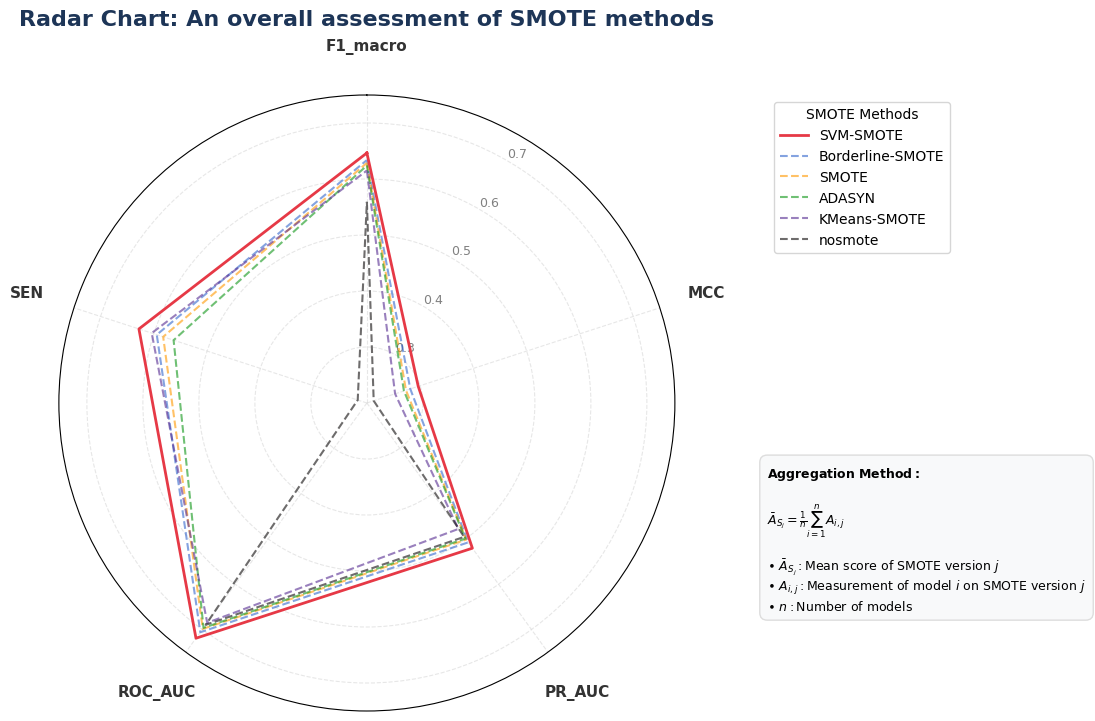

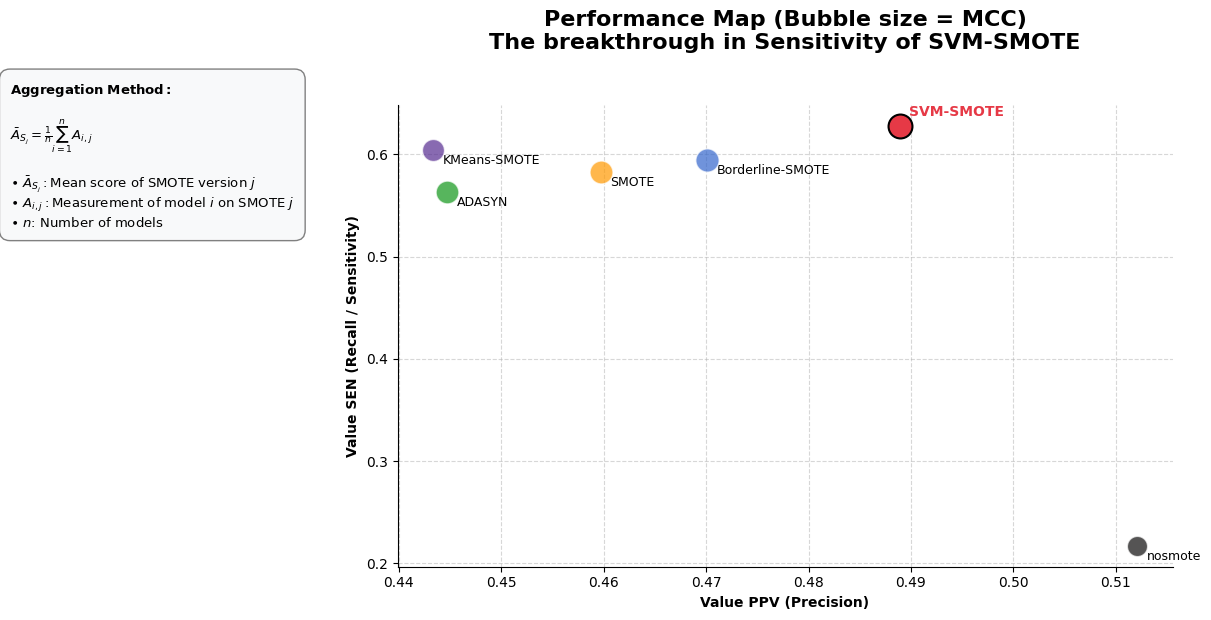

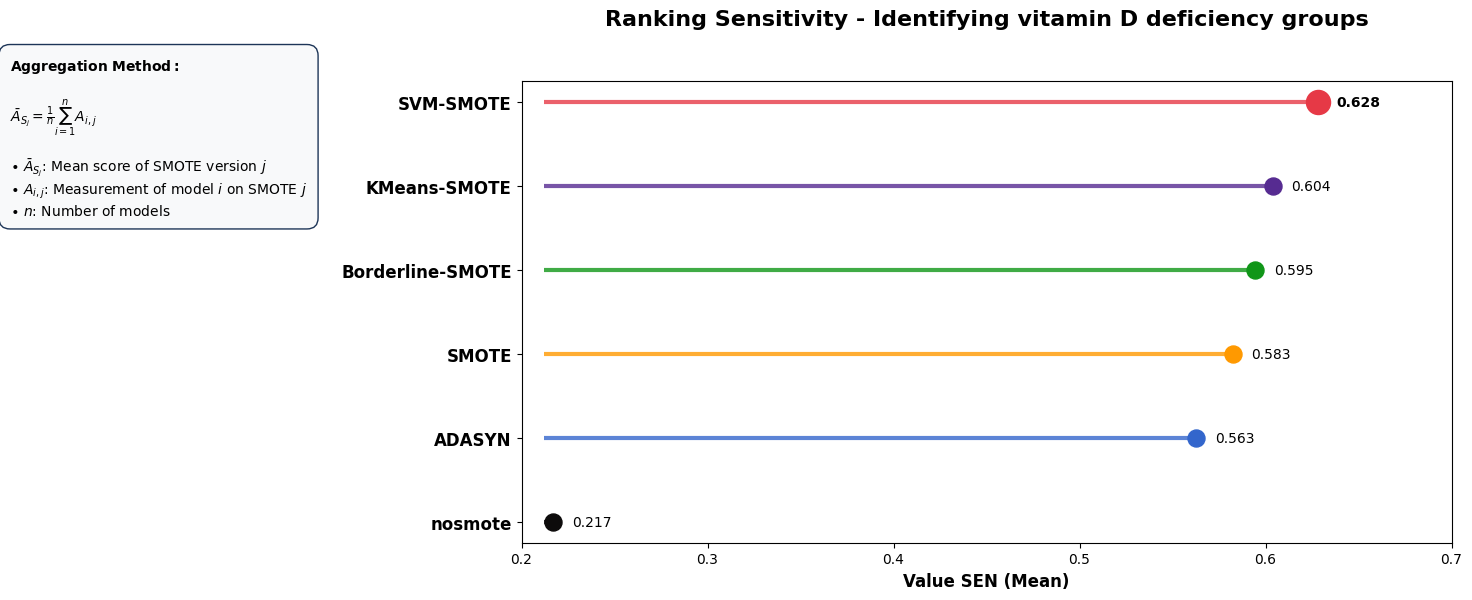

In [12]:

df = pd.read_csv('../results/clean_experiment/analysis/smote_summary.csv', header=[0, 1], index_col=0)

name_map = {
    'svm_smote': 'SVM-SMOTE',
    'borderline_smote': 'Borderline-SMOTE',
    'smote': 'SMOTE',
    'adasyn': 'ADASYN',
    'kmeans_smote': 'KMeans-SMOTE'
}
df.rename(index=name_map, inplace=True)
smote_techs = df.index.tolist()

highlight_color = '#E63946' 
nosmote_color = "#0D0B0B"   
base_colors = ['#3366CC', '#FF9900', '#109618', "#562B91"] 

def get_colors(techs):
    colors = []
    base_idx = 0
    for t in techs:
        t_lower = t.lower()
        if 'svm-smote' in t_lower:
            colors.append(highlight_color)
        elif 'no-smote' in t_lower or 'nosmote' in t_lower:
            colors.append(nosmote_color) 
        else:
            colors.append(base_colors[base_idx % len(base_colors)])
            base_idx += 1
    return colors

color_list = get_colors(smote_techs)

# --- CHART 1: RADAR CHART (CĂN CHỈNH THẲNG HÀNG) ---
fig1, ax1 = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))

ax1.set_theta_offset(pi / 2)
ax1.set_theta_direction(-1) 

for i, tech in enumerate(smote_techs):
    values = df.loc[tech, [(m, 'mean') for m in metrics_radar]].values.flatten().tolist()
    values += values[:1]
    
    if tech == 'SVM-SMOTE':
        ax1.plot(angles, values, linewidth=2, linestyle='solid', color=highlight_color, label=f'{tech}', zorder=5)
        # ax1.fill(angles, values, color=highlight_color, alpha=0.1)
    else:
        ax1.plot(angles, values, linewidth=1.5, linestyle='--', color=color_list[i], alpha=0.6, label=tech, zorder=3)

plt.xticks(angles[:-1], metrics_radar, color='#333333', size=11, fontweight='bold')
ax1.tick_params(axis='x', pad=25) # Đẩy chữ ra xa tí cho thoáng

ax1.set_ylim(0.2, 0.75) 
ax1.set_rlabel_position(30) 
plt.yticks([0.3, 0.4, 0.5, 0.6, 0.7], ["0.3", "0.4", "0.5", "0.6", "0.7"], color="grey", size=9)
ax1.grid(True, color='#DDDDDD', linestyle='--', alpha=0.7) 

plt.legend(loc='upper left', bbox_to_anchor=(1.15, 1.0), fontsize=10, frameon=True, title="SMOTE Methods")

formula_radar = (
    r"$\bf{Aggregation\ Method:}$" + "\n\n" +
    r"$\bar{A}_{S_j} = \frac{1}{n} \sum_{i=1}^{n} A_{i,j}$" + "\n\n" +
    r"$\bullet\ \bar{A}_{S_j}: \text{Mean score of SMOTE version } j$" + "\n" +
    r"$\bullet\ A_{i,j}: \text{Measurement of model } i \text{ on SMOTE version } j$" + "\n" +
    r"$\bullet\ n: \text{Number of models}$"
)

ax1.text(1.15, 0.4, formula_radar, transform=ax1.transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='left',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='#F8F9FA', alpha=1, edgecolor='#DDDDDD'))

plt.title('Radar Chart: An overall assessment of SMOTE methods', size=16, fontweight='bold', y=1.1, color='#1D3557', x=0.5)

plt.subplots_adjust(right=0.75)

plt.savefig('smote_chart1_radar_aligned.png', dpi=300, bbox_inches='tight')
plt.show()

# CHART 2: SCATTER PLOT
fig2, ax2 = plt.subplots(figsize=(10, 6))

ppv_mean = df[('PPV', 'mean')]
sen_mean = df[('SEN', 'mean')]
mcc_mean = df[('MCC', 'mean')] * 1000 

for i, tech in enumerate(smote_techs):
    if tech == 'SVM-SMOTE':
        ax2.scatter(ppv_mean[tech], sen_mean[tech], s=mcc_mean[tech], color=highlight_color, edgecolor='black', linewidth=1.5, marker='o', zorder=5, label=tech)
        ax2.annotate(tech, (ppv_mean[tech], sen_mean[tech]), xytext=(7, 7), textcoords='offset points', fontweight='bold', color=highlight_color)
    else:
        ax2.scatter(ppv_mean[tech], sen_mean[tech], s=mcc_mean[tech], color=color_list[i], alpha=0.7, edgecolor='white', marker='o', zorder=4)
        ax2.annotate(tech, (ppv_mean[tech], sen_mean[tech]), xytext=(7, -10), textcoords='offset points', fontsize=9)

ax2.set_xlabel('Value PPV (Precision)', fontsize=10, fontweight='bold')
ax2.set_ylabel('Value SEN (Recall / Sensitivity)', fontsize=10, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

formula_text_2 = (
    r"$\bf{Aggregation\ Method:}$" + "\n\n" +
    r"$\bar{A}_{S_j} = \frac{1}{n} \sum_{i=1}^{n} A_{i,j}$" + "\n\n" +
    r"$\bullet$ $\bar{A}_{S_j}: \text{Mean score of SMOTE version } j$" + "\n" +
    r"$\bullet$ $A_{i,j}: \text{Measurement of model } i \text{ on SMOTE } j$" + "\n" +
    r"$\bullet$ $n$: Number of models"
)

ax2.text(-0.50, 1.05, formula_text_2, transform=ax2.transAxes, fontsize=9.5,
         verticalalignment='top', horizontalalignment='left',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='#F8F9FA', alpha=1, edgecolor='gray', linewidth=1))

ax2.set_title('Performance Map (Bubble size = MCC)\nThe breakthrough in Sensitivity of SVM-SMOTE', 
             fontsize=16, fontweight='bold', pad=40)

plt.savefig('smote_chart2_scatter_expanded.png', dpi=300, bbox_inches='tight')
plt.show()

# --- CHART 3: LOLLIPOP CHART (MỞ RỘNG KHUNG - KHÔNG CO CHART) ---
fig3, ax3 = plt.subplots(figsize=(12, 6))

df_sen = df.sort_values(by=('SEN', 'mean'), ascending=True)
techs_sorted = df_sen.index.tolist()
sen_vals = df_sen[('SEN', 'mean')].values
colors_sorted = get_colors(techs_sorted)
y_pos = np.arange(len(techs_sorted))

ax3.hlines(y=y_pos, xmin=min(sen_vals)-0.005, xmax=sen_vals, color=colors_sorted, linewidth=3, alpha=0.8)
for i, tech in enumerate(techs_sorted):
    size = 300 if tech == 'SVM-SMOTE' else 150
    ax3.scatter(sen_vals[i], y_pos[i], color=colors_sorted[i], s=size, zorder=3)
    ax3.text(sen_vals[i] + 0.01, y_pos[i], f"{sen_vals[i]:.3f}", va='center', 
             fontweight='bold' if tech == 'SVM-SMOTE' else 'normal')

ax3.set_yticks(y_pos)
ax3.set_xlim(0.2, 0.7)
ax3.set_yticklabels(techs_sorted, fontsize=12, fontweight='bold')
ax3.set_xlabel('Value SEN (Mean)', fontsize=12, fontweight='bold')


formula_text_3 = (
    r"$\bf{Aggregation\ Method:}$" + "\n\n" +
    r"$\bar{A}_{S_j} = \frac{1}{n} \sum_{i=1}^{n} A_{i,j}$" + "\n\n" +
    r"$\bullet$ $\bar{A}_{S_j}$: Mean score of SMOTE version $j$" + "\n" +
    r"$\bullet$ $A_{i,j}$: Measurement of model $i$ on SMOTE $j$" + "\n" +
    r"$\bullet$ $n$: Number of models"
)

ax3.text(-0.55, 1.05, formula_text_3, transform=ax3.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='left',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='#F8F9FA', alpha=1, edgecolor='#1D3557', linewidth=1))

ax3.set_title('Ranking Sensitivity - Identifying vitamin D deficiency groups', 
             fontsize=16, fontweight='bold', pad=40)

plt.savefig('smote_chart3_lollipop_separated.png', dpi=300, bbox_inches='tight')
plt.show()



#### Deep Learning

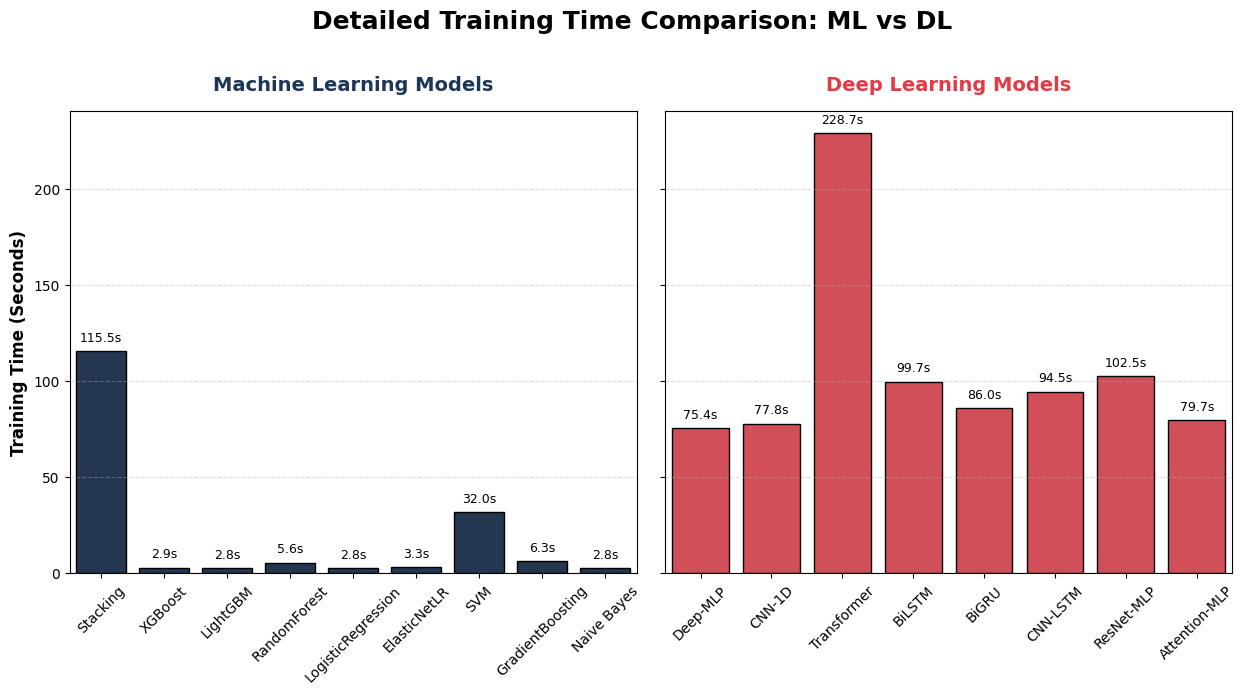

In [7]:
df = pd.read_csv('../results/clean_experiment/analysis/model_summary.csv')


ml_models = ['Stacking', 'XGBoost', 'RandomForest', 'LogisticRegression', 'ElasticNetLR', 
             'SVM', 'GradientBoosting', 'LightGBM', 'Naive Bayes']
dl_models = ['CNN-1D', 'Deep-MLP', 'BiGRU', 'BiLSTM', 'Attention-MLP', 
             'ResNet-MLP', 'CNN-LSTM', 'Transformer']

df['Category'] = df['Model'].apply(lambda x: 'Machine Learning' if x in ml_models else 'Deep Learning')

df_ml = df[df['Category'] == 'Machine Learning'].sort_values('MCC', ascending=False)
df_dl = df[df['Category'] == 'Deep Learning'].sort_values('MCC', ascending=False)

color_ml = '#1D3557' 
color_dl = '#E63946' 

# CHART 1: 
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True, gridspec_kw={'wspace': 0.05})

sns.barplot(data=df_ml, x='Model', y='Training time', color=color_ml, ax=ax1, edgecolor='black')
ax1.set_title('Machine Learning Models', fontsize=14, fontweight='bold', color=color_ml, pad=15)
ax1.set_ylabel('Training Time (Seconds)', fontsize=12, fontweight='bold')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=45)

for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.1f}s", (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=9, rotation=0)

sns.barplot(data=df_dl, x='Model', y='Training time', color=color_dl, ax=ax2, edgecolor='black')
ax2.set_title('Deep Learning Models', fontsize=14, fontweight='bold', color=color_dl, pad=15)
ax2.set_ylabel('') 
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=45)

for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.1f}s", (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=9, rotation=0)

fig1.suptitle('Detailed Training Time Comparison: ML vs DL', fontsize=18, fontweight='bold', y=1.05)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.savefig('chart1_time_individual_split.png', dpi=300, bbox_inches='tight')


# Chart 2
metrics = ['F1_macro', 'MCC', 'SEN', 'PR_AUC']
for metric in metrics:
    df_ml = df[df['Category'] == 'Machine Learning'].sort_values(by=metric, ascending=False)
    df_dl = df[df['Category'] == 'Deep Learning'].sort_values(by=metric, ascending=False)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True, gridspec_kw={'wspace': 0.05})
    
    sns.barplot(data=df_ml, x='Model', y=metric, color=color_ml, ax=ax1, edgecolor='black', linewidth=1)
    ax1.set_title('Machine Learning Models', fontsize=14, fontweight='bold', color=color_ml, pad=15)
    ax1.set_ylabel(f'Score ({metric})', fontsize=12, fontweight='bold')
    ax1.set_xlabel('')
    ax1.tick_params(axis='x', rotation=40)
    
    for p in ax1.patches:
        ax1.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', 
                     fontsize=10, fontweight='bold', color='#333333', rotation=45)
        
    sns.barplot(data=df_dl, x='Model', y=metric, color=color_dl, ax=ax2, edgecolor='black', linewidth=1)
    ax2.set_title('Deep Learning Models', fontsize=14, fontweight='bold', color=color_dl, pad=15)
    ax2.set_ylabel('') 
    ax2.set_xlabel('')
    ax2.tick_params(axis='x', rotation=40)
    
    for p in ax2.patches:
        ax2.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', 
                     fontsize=10, fontweight='bold', color='#333333', rotation=45)

    max_val = max(df_ml[metric].max(), df_dl[metric].max())
    ax1.set_ylim(0, max_val * 1.3)
    
    ax1.grid(axis='y', linestyle='--', alpha=0.4)
    ax2.grid(axis='y', linestyle='--', alpha=0.4)
    
    fig.suptitle(f'Detailed Comparison: {metric} Score (Sorted Descending)', fontsize=18, fontweight='bold', y=1.05)
    
    plt.savefig(f'comparison_split_{metric}.png', dpi=300, bbox_inches='tight')
    plt.close() 


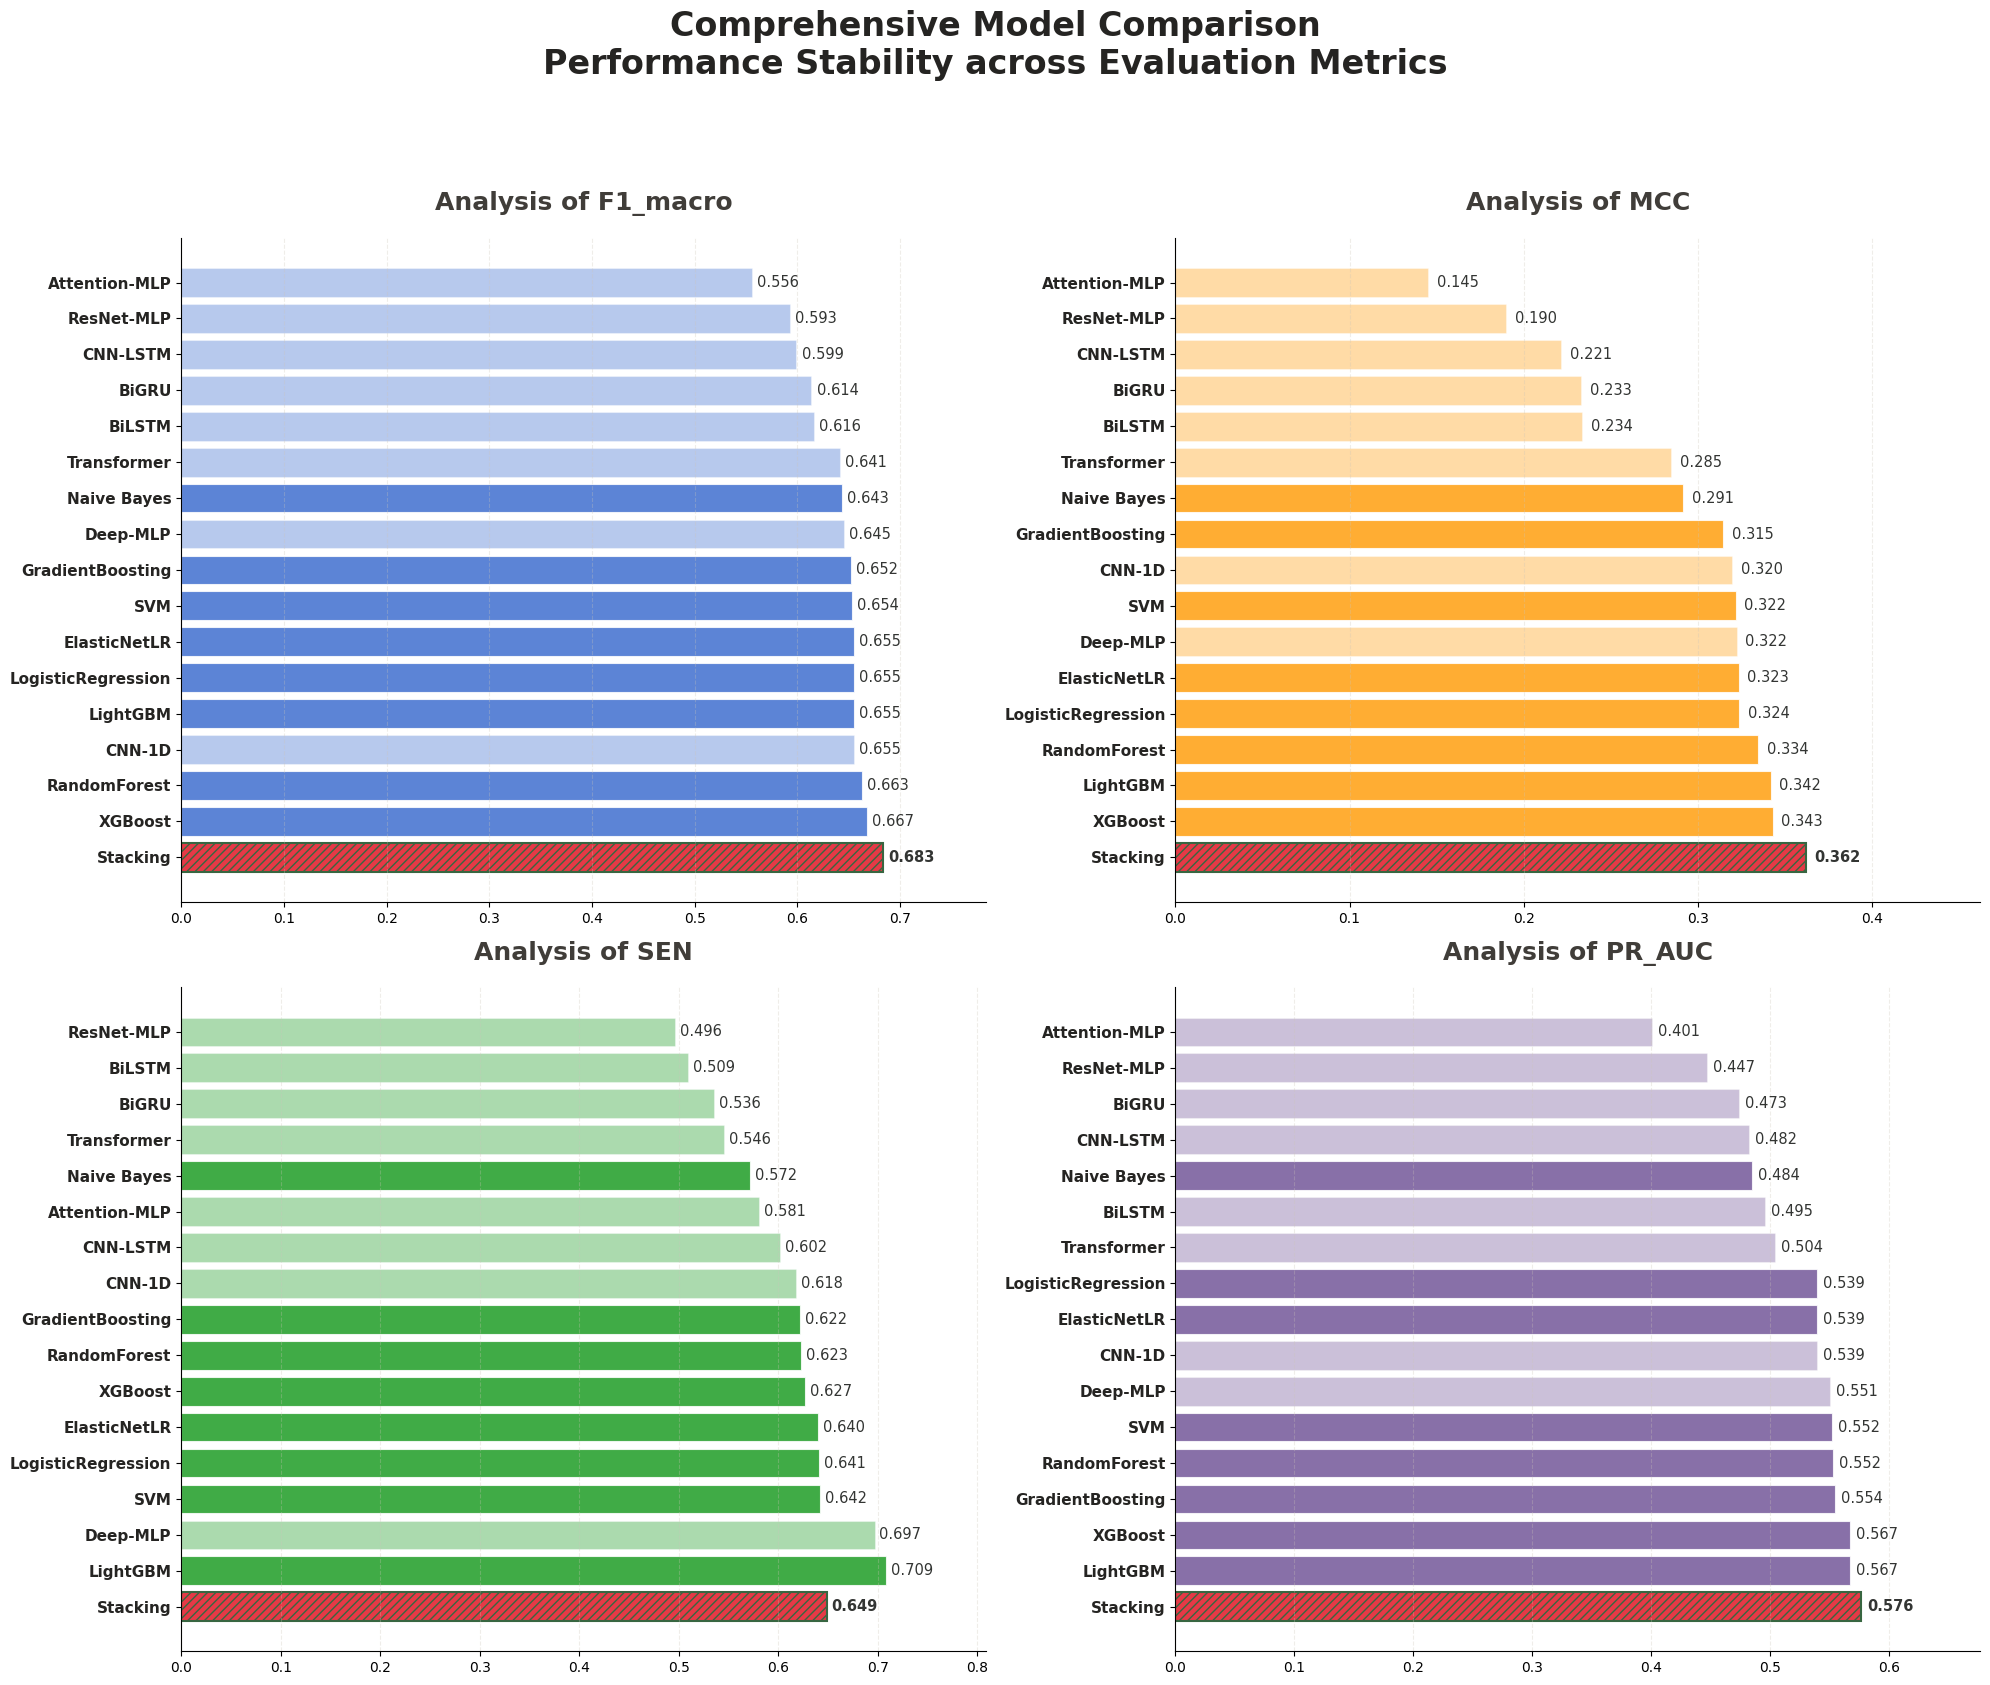

In [8]:
metrics = ['F1_macro', 'MCC', 'SEN', 'PR_AUC']
colors_palette = ['#3366CC', '#FF9900', '#109618', '#6A4C93'] 
stacking_color = '#E63946' 

fig, axes = plt.subplots(2, 2, figsize=(20, 16), sharey=False)
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    df_stacking = df[df['Model'] == 'Stacking']
    df_others = df[df['Model'] != 'Stacking'].copy()
    df_others_sorted = df_others.sort_values(by=metric, ascending=True)
    final_plot_df = pd.concat([df_others_sorted, df_stacking])
    
    models = final_plot_df['Model'].values
    values = final_plot_df[metric].values
    y_pos = np.arange(len(models))
    
    for j, (model, val) in enumerate(zip(models, values)):
        if model == 'Stacking':
            color = stacking_color
            edge = '#386641' 
            lw = 1.5
            hatch = '////' 
            alpha = 1.0
        elif model in ml_models:
            color = colors_palette[i]
            edge = 'white'
            lw = 0.8
            hatch = ''
            alpha = 0.8 
        else: 
            color = colors_palette[i]
            edge = 'white'
            lw = 0.8
            hatch = ''
            alpha = 0.35 

        ax.barh(j, val, color=color, edgecolor=edge, linewidth=lw, hatch=hatch, alpha=alpha)
        
        ax.text(val + 0.005, j, f'{val:.3f}', va='center', fontsize=10.5, 
                fontweight='bold' if model == 'Stacking' else 'normal',
                color='#333533')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(models, fontsize=11, fontweight='semibold', color='#252422')
    ax.invert_yaxis() 
    
    ax.set_title(f'Analysis of {metric}', fontsize=18, fontweight='bold', pad=20, color='#403D39')
    ax.set_xlim(0, max(values) + 0.1)
    
    ax.grid(axis='x', linestyle='--', alpha=0.3, color='#CCC5B9')
    
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

fig.suptitle('Comprehensive Model Comparison\nPerformance Stability across Evaluation Metrics', 
             fontsize=24, fontweight='bold', y=1.05, color='#252422')

plt.tight_layout()
plt.savefig('final_professional_muted.png', dpi=300, bbox_inches='tight')
plt.show()